In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pz̄d.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/fault-tolerance-synthetic-data/calibration_only_params.json
/kaggle/input/fault-tolerance-synthetic-data/synthetic_ground_truth.csv
/kaggle/input/fault-tolerance-synthetic-data/synthetic_sensor_logs.txt
/kaggle/input/fault-tolerance-synthetic-data/frozen_calibration_metrics.json
/kaggle/input/fault-tolerance-synthetic-data/calibration_only_predictions.csv


In [2]:
import json
import pandas as pd
import re
from datetime import datetime


df_logs = pd.read_csv(
    "/kaggle/input/fault-tolerance-synthetic-data/synthetic_sensor_logs.txt",
    header=None,
    names=["raw"]
)

df_true = pd.read_csv(
    "/kaggle/input/fault-tolerance-synthetic-data/synthetic_ground_truth.csv",
    parse_dates=["timestamp"]
)

df_calib_preds = pd.read_csv(
    "/kaggle/input/fault-tolerance-synthetic-data/calibration_only_predictions.csv"
)

with open("/kaggle/input/fault-tolerance-synthetic-data/calibration_only_params.json") as f:
    calib_params = json.load(f)

with open("/kaggle/input/fault-tolerance-synthetic-data/frozen_calibration_metrics.json") as f:
    frozen_metrics = json.load(f)


In [3]:
import pandas as pd

calib_faulty_adv = pd.read_csv(
    "/kaggle/input/fault-tolerance-synthetic-data/calibration_only_predictions.csv"
)


In [4]:
assert "baseline" in frozen_metrics
assert "calibration_only" in frozen_metrics
assert len(calib_params) > 0


In [5]:
SOIL_PATTERN = re.compile(
    r"Sender (?P<sender>\d+):,0,\s*"
    r"S\d+M1:\s*,(?P<M1>[-\d\.]+),"
    r"S\d+M2:\s*,(?P<M2>[-\d\.]+),"
    r"S\d+T1:\s*,(?P<T1>[-\d\.]+),"
    r"S\d+T2:\s*,(?P<T2>[-\d\.]+),"
    r"DepthOfRain:\s*,(?P<R>[-\d\.]+)"
)

PRESSURE_PATTERN = re.compile(
    r"Sender 101:,Pressure_kPa:\s*,(?P<P>[-\d\.]+)"
)

def parse_sensor_logs(filepath: str, strict: bool = False):
    records = []
    error_log = []

    with open(filepath, "r") as f:
        for line_num, line in enumerate(f, start=1):
            line = line.strip()
            if not line:
                continue

            try:
                ts_str, pkt_id, payload = line.split(",", 2)
                timestamp = datetime.strptime(ts_str, "%Y-%m-%d %H:%M:%S")
                packet_id = int(pkt_id)

                if "Pressure_kPa" in payload:
                    m = PRESSURE_PATTERN.search(payload)
                    if not m:
                        raise ValueError("Pressure regex failed")

                    records.append([
                        timestamp, packet_id, 101,
                        "pressure", "P", float(m.group("P"))
                    ])
                else:
                    m = SOIL_PATTERN.search(payload)
                    if not m:
                        raise ValueError("Soil regex failed")

                    sender = int(m.group("sender"))

                    records.extend([
                        [timestamp, packet_id, sender, "moisture", "M1", float(m.group("M1"))],
                        [timestamp, packet_id, sender, "moisture", "M2", float(m.group("M2"))],
                        [timestamp, packet_id, sender, "temperature", "T1", float(m.group("T1"))],
                        [timestamp, packet_id, sender, "temperature", "T2", float(m.group("T2"))],
                        [timestamp, packet_id, sender, "rain", "R", float(m.group("R"))],
                    ])

            except Exception as e:
                if strict:
                    raise
                error_log.append((line_num, line, str(e)))

    df = pd.DataFrame(
        records,
        columns=["timestamp", "packet_id", "sender", "modality", "probe", "value"]
    )

    return df, error_log


In [6]:
def add_time_index(df, window_minutes=5):
    df = df.copy()
    t0 = df["timestamp"].min()
    delta = pd.to_timedelta(window_minutes, unit="min")
    df["time_index"] = ((df["timestamp"] - t0) // delta).astype(int)
    return df


In [7]:
def to_wide(df_t):
    return (
        df_t
        .pivot_table(
            index=["time_index", "sender"],
            columns=["modality", "probe"],
            values="value"
        )
        .sort_index()
    )


In [8]:
# reuse: parse_sensor_logs, add_time_index, to_wide
df_logs, _ = parse_sensor_logs("/kaggle/input/fault-tolerance-synthetic-data/synthetic_sensor_logs.txt")
df_logs = add_time_index(df_logs, window_minutes=5)

df_t = (
    df_logs
    .groupby(["time_index", "sender", "modality", "probe"], as_index=False)
    .agg({"value": "mean"})
)


In [9]:
np.random.seed(123)

fault_times = np.random.choice(
    df_t.time_index.unique(),
    size=8,
    replace=False
)

fault_times = np.sort(fault_times)
print("Fault windows:", fault_times)


Fault windows: [ 53  72  87  91 127 129 138 146]


In [10]:
df_faulty = df_t.copy()

fault_mask = (
    (df_faulty.time_index.isin(fault_times)) &
    (df_faulty.sender == 2) &
    (df_faulty.modality == "moisture") &
    (df_faulty.probe == "M1")
)

df_faulty.loc[fault_mask, "value"] += 15


In [11]:
wide_faulty = to_wide(df_faulty)


In [12]:
def ema(series, alpha=0.3):
    return series.ewm(alpha=alpha, adjust=False).mean()


In [13]:
def baseline_estimator(wide_df, alpha=0.3):
    """
    Reference baseline:
    - Average redundant probes
    - EMA smoothing
    """
    outputs = []

    for sender in wide_df.index.get_level_values("sender").unique():
        df_s = wide_df.xs(sender, level="sender")

        # Moisture
        if ("moisture", "M1") in df_s and ("moisture", "M2") in df_s:
            moist = df_s[[("moisture", "M1"), ("moisture", "M2")]].mean(axis=1)
            moist_hat = ema(moist, alpha)

            outputs.append(pd.DataFrame({
                "time_index": moist_hat.index,
                "sender": sender,
                "modality": "moisture",
                "estimate": moist_hat.values
            }))

        # Temperature
        if ("temperature", "T1") in df_s and ("temperature", "T2") in df_s:
            temp = df_s[[("temperature", "T1"), ("temperature", "T2")]].mean(axis=1)
            temp_hat = ema(temp, alpha)

            outputs.append(pd.DataFrame({
                "time_index": temp_hat.index,
                "sender": sender,
                "modality": "temperature",
                "estimate": temp_hat.values
            }))

        # Pressure (node 101 only)
        if sender == 101 and ("pressure", "P") in df_s:
            press_hat = ema(df_s[("pressure", "P")], alpha)

            outputs.append(pd.DataFrame({
                "time_index": press_hat.index,
                "sender": sender,
                "modality": "pressure",
                "estimate": press_hat.values
            }))

    return pd.concat(outputs, ignore_index=True)


In [14]:
baseline_faulty = baseline_estimator(wide_faulty, alpha=0.3)
baseline_faulty = baseline_faulty.rename(columns={"estimate": "value"})


In [15]:
def apply_frozen_calibration(wide_df, calib_params):
    outputs = []

    for key, p in calib_params.items():
        sender, modality, probe = key.split("_")
        sender = int(sender)

        alpha = p["alpha"]
        beta = p["beta"]

        if (modality, probe) not in wide_df.columns:
            continue

        y = (wide_df[(modality, probe)] - beta) / alpha

        outputs.append(pd.DataFrame({
            "time_index": y.index.get_level_values("time_index"),
            "sender": sender,
            "modality": modality,
            "value": y.values
        }))

    return pd.concat(outputs, ignore_index=True)


In [16]:
calib_faulty = apply_frozen_calibration(wide_faulty, calib_params)


In [17]:
df_true_eval = (
    df_true
    .assign(time_index=lambda d:
            ((d.timestamp - d.timestamp.min())
             // pd.to_timedelta(5, "min")).astype(int))
    .groupby(["time_index", "sender", "modality"], as_index=False)
    .agg({"value": "mean"})
)


In [18]:
def rmse(df_true, df_hat, modality):
    merged = (
        df_true[df_true.modality == modality]
        .merge(
            df_hat[df_hat.modality == modality],
            on=["time_index", "sender"],
            suffixes=("_true", "_hat")
        )
    )
    return np.sqrt(
        np.mean((merged.value_hat - merged.value_true) ** 2)
    )


In [19]:
def fault_penalty(df_true, df_hat, fault_times, modality):
    """
    Difference between RMSE during fault windows
    and RMSE during clean windows.
    """
    clean_mask = ~df_true.time_index.isin(fault_times)
    fault_mask = df_true.time_index.isin(fault_times)

    rmse_clean = rmse(df_true[clean_mask], df_hat, modality)
    rmse_fault = rmse(df_true[fault_mask], df_hat, modality)

    return rmse_fault - rmse_clean


In [20]:
print(
    "Baseline fault penalty:",
    fault_penalty(df_true_eval, baseline_faulty, fault_times, "moisture")
)

print(
    "Calibration-only fault penalty:",
    fault_penalty(df_true_eval, calib_faulty, fault_times, "moisture")
)


Baseline fault penalty: -0.4316807879019753
Calibration-only fault penalty: -7.167751966270625


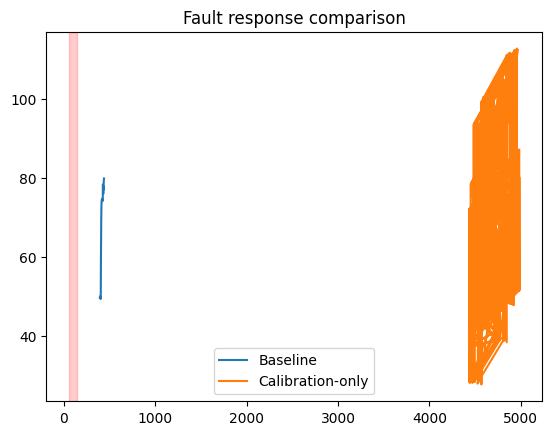

In [21]:
import matplotlib.pyplot as plt

sender = 2

plt.plot(
    baseline_faulty[
        (baseline_faulty.sender == sender) &
        (baseline_faulty.modality == "moisture")
    ].sort_values("time_index").value,
    label="Baseline"
)

plt.plot(
    calib_faulty[
        (calib_faulty.sender == sender) &
        (calib_faulty.modality == "moisture")
    ].sort_values("time_index").value,
    label="Calibration-only"
)

plt.axvspan(fault_times.min(), fault_times.max(),
            color="red", alpha=0.2)

plt.legend()
plt.title("Fault response comparison")
plt.show()


In [22]:
def localized_fault_penalty(
    df_true, df_hat, fault_times, modality, sender
):
    df_true_s = df_true[
        (df_true.sender == sender) &
        (df_true.modality == modality)
    ]

    df_hat_s = df_hat[
        (df_hat.sender == sender) &
        (df_hat.modality == modality)
    ]

    clean = ~df_true_s.time_index.isin(fault_times)
    fault = df_true_s.time_index.isin(fault_times)

    rmse_clean = rmse(df_true_s[clean], df_hat_s, modality)
    rmse_fault = rmse(df_true_s[fault], df_hat_s, modality)

    return rmse_fault - rmse_clean


In [23]:
print(
    "Baseline localized fault penalty:",
    localized_fault_penalty(
        df_true_eval,baseline_faulty,
        fault_times,"moisture",sender=2
    )
)

print(
    "Calibration-only localized fault penalty:",
    localized_fault_penalty(
        df_true_eval,calib_faulty,
        fault_times,"moisture",sender=2
    )
)

Baseline localized fault penalty: 0.3772920246242726
Calibration-only localized fault penalty: -1.4297494271934887


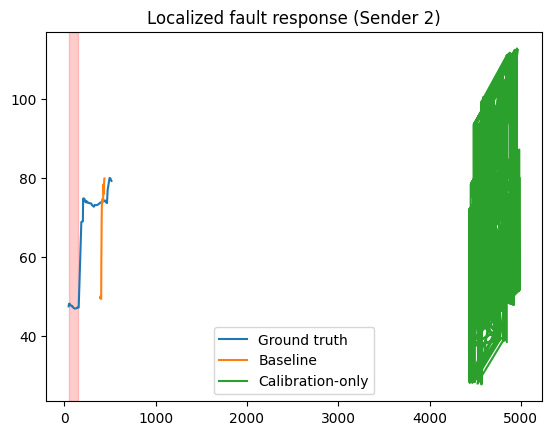

In [24]:
plt.plot(
    df_true_eval[
        (df_true_eval.sender == 2) &
        (df_true_eval.modality == "moisture")
    ].sort_values("time_index").value,
    label="Ground truth"
)

plt.plot(
    baseline_faulty[
        (baseline_faulty.sender == 2) &
        (baseline_faulty.modality == "moisture")
    ].sort_values("time_index").value,
    label="Baseline"
)

plt.plot(
    calib_faulty[
        (calib_faulty.sender == 2) &
        (calib_faulty.modality == "moisture")
    ].sort_values("time_index").value,
    label="Calibration-only"
)

plt.axvspan(
    fault_times.min(), fault_times.max(),
    color="red", alpha=0.2
)

plt.legend()
plt.title("Localized fault response (Sender 2)")
plt.show()


In [25]:
df_faulty_adv = df_t.copy()

mask_m1 = (
    (df_faulty_adv.time_index.isin(fault_times)) &
    (df_faulty_adv.sender == 2) &
    (df_faulty_adv.modality == "moisture") &
    (df_faulty_adv.probe == "M1")
)

mask_m2 = (
    (df_faulty_adv.time_index.isin(fault_times)) &
    (df_faulty_adv.sender == 2) &
    (df_faulty_adv.modality == "moisture") &
    (df_faulty_adv.probe == "M2")
)

df_faulty_adv.loc[mask_m1, "value"] += 15
df_faulty_adv.loc[mask_m2, "value"] -= 15


In [26]:
wide_faulty_adv = to_wide(df_faulty_adv)


In [27]:
baseline_faulty_adv = baseline_estimator(wide_faulty_adv, alpha=0.3)
baseline_faulty_adv = baseline_faulty_adv.rename(columns={"estimate": "value"})


In [28]:
calib_faulty_adv = apply_frozen_calibration(
    wide_faulty_adv, calib_params
)


In [29]:
print(
    "Baseline adversarial localized fault penalty:",
    localized_fault_penalty(
        df_true_eval,
        baseline_faulty_adv,
        fault_times,
        modality="moisture",
        sender=2
    )
)

print(
    "Calibration-only adversarial localized fault penalty:",
    localized_fault_penalty(
        df_true_eval,
        calib_faulty_adv,
        fault_times,
        modality="moisture",
        sender=2
    )
)


Baseline adversarial localized fault penalty: -1.9036858386921736
Calibration-only adversarial localized fault penalty: 0.4275353662388319


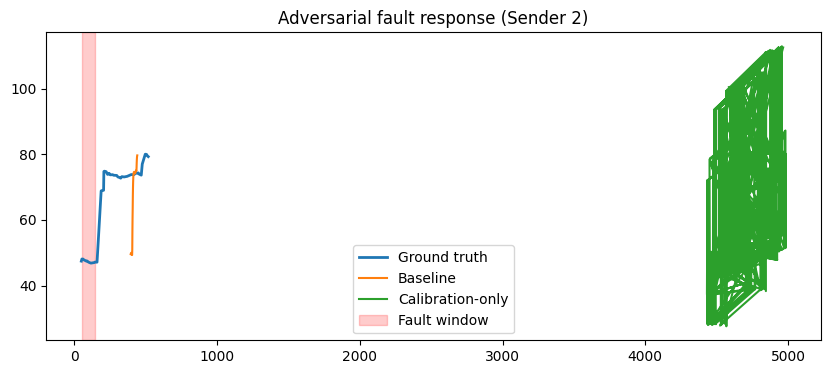

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.plot(
    df_true_eval[
        (df_true_eval.sender == 2) &
        (df_true_eval.modality == "moisture")
    ].sort_values("time_index").value,
    label="Ground truth",
    linewidth=2
)

plt.plot(
    baseline_faulty_adv[
        (baseline_faulty_adv.sender == 2) &
        (baseline_faulty_adv.modality == "moisture")
    ].sort_values("time_index").value,
    label="Baseline"
)

plt.plot(
    calib_faulty_adv[
        (calib_faulty_adv.sender == 2) &
        (calib_faulty_adv.modality == "moisture")
    ].sort_values("time_index").value,
    label="Calibration-only"
)

plt.axvspan(
    fault_times.min(), fault_times.max(),
    color="red", alpha=0.2, label="Fault window"
)

plt.legend()
plt.title("Adversarial fault response (Sender 2)")
plt.show()


In [31]:
def to_node_matrix(df_hat, modality, node_ids):
    df_f = (
        df_hat[df_hat.modality == modality]
        .groupby(["time_index", "sender"], as_index=False)
        .agg({"value": "mean"})
    )

    mat = (
        df_f
        .pivot(index="time_index", columns="sender", values="value")
        .reindex(columns=node_ids)
        .sort_index()
    )
    return mat


In [32]:
NODE_IDS = [0, 1, 2, 3, 4, 101]
NUM_NODES = len(NODE_IDS)

# Fully connected adjacency with self-loops
A = np.ones((NUM_NODES, NUM_NODES), dtype=np.float32)

# Symmetric normalization
D_inv_sqrt = np.diag(1.0 / np.sqrt(A.sum(axis=1)))
A_norm = D_inv_sqrt @ A @ D_inv_sqrt

# Sanity checks
assert A_norm.shape == (NUM_NODES, NUM_NODES)
assert np.allclose(A_norm, A_norm.T)


In [33]:
import numpy as np


In [34]:
def graph_temporal_smoothing(theta_calib, A_norm, lam=0.3):
    theta_graph = theta_calib.copy().values
    T, N = theta_graph.shape

    for t in range(1, T):
        prev = theta_graph[t-1]
        curr = theta_graph[t]

        # skip missing
        mask = ~np.isnan(curr)
        smooth = A_norm @ np.nan_to_num(prev)

        theta_graph[t, mask] = (
            (1 - lam) * curr[mask] +
            lam * smooth[mask]
        )

    return pd.DataFrame(
        theta_graph,
        index=theta_calib.index,
        columns=theta_calib.columns
    )


In [36]:
NODE_IDS = [0, 1, 2, 3, 4, 101]

theta_calib = to_node_matrix(
    calib_faulty_adv,
    modality="moisture",
    node_ids=NODE_IDS
)


In [37]:
theta_graph = graph_temporal_smoothing(
    theta_calib,
    A_norm,
    lam=0.3
)


In [38]:
def to_long(theta_mat, modality):
    return (
        theta_mat
        .reset_index()
        .melt(
            id_vars="time_index",
            var_name="sender",
            value_name="value"
        )
        .assign(modality=modality)
        .dropna()
    )


In [39]:
graph_out = to_long(theta_graph, modality="moisture")


In [40]:
print(
    "Graph-based adversarial localized fault penalty:",
    localized_fault_penalty(
        df_true_eval,
        graph_out,
        fault_times,
        modality="moisture",
        sender=2
    )
)


Graph-based adversarial localized fault penalty: 1.6219085774636675


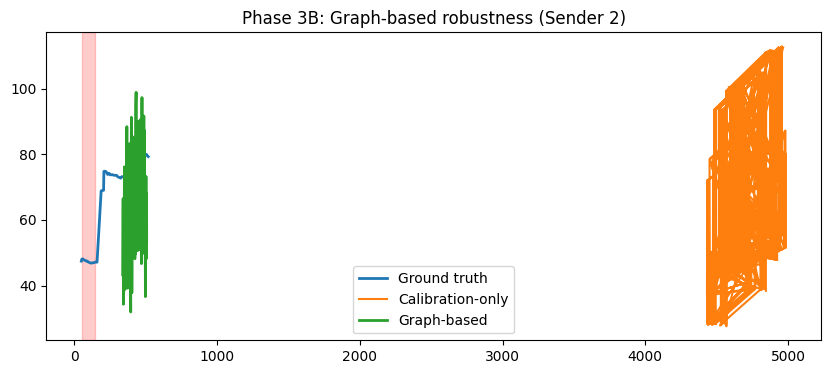

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.plot(
    df_true_eval[
        (df_true_eval.sender == 2) &
        (df_true_eval.modality == "moisture")
    ].sort_values("time_index").value,
    label="Ground truth",
    linewidth=2
)

plt.plot(
    calib_faulty_adv[
        (calib_faulty_adv.sender == 2) &
        (calib_faulty_adv.modality == "moisture")
    ].sort_values("time_index").value,
    label="Calibration-only"
)

plt.plot(
    graph_out[
        (graph_out.sender == 2)
    ].sort_values("time_index").value,
    label="Graph-based",
    linewidth=2
)

plt.axvspan(
    fault_times.min(),
    fault_times.max(),
    color="red",
    alpha=0.2
)

plt.legend()
plt.title("Phase 3B: Graph-based robustness (Sender 2)")
plt.show()


In [42]:
for lam in [0.05, 0.1, 0.15]:
    theta_graph = graph_temporal_smoothing(
        theta_calib,
        A_norm,
        lam=lam
    )

    graph_out = to_long(theta_graph, modality="moisture")

    penalty = localized_fault_penalty(
        df_true_eval,
        graph_out,
        fault_times,
        modality="moisture",
        sender=2
    )

    print(f"λ = {lam:.2f} → fault penalty = {penalty:.3f}")


λ = 0.05 → fault penalty = -2.952
λ = 0.10 → fault penalty = -2.281
λ = 0.15 → fault penalty = -1.382


In [43]:
import matplotlib.pyplot as plt

sender_id = 1  # choose a representative node

df_m = df_t[
    (df_t.sender == sender_id) &
    (df_t.modality == "moisture")
]

pivot = (
    df_m
    .pivot_table(index="time_index", columns="probe", values="value")
    .dropna()
)

plt.figure(figsize=(7, 4))
plt.plot(pivot.index, pivot["M1"], label="M1", linewidth=1.5)
plt.plot(pivot.index, pivot["M2"], label="M2", linewidth=1.5)

plt.xlabel("Time index")
plt.ylabel("Measured moisture")
plt.title(f"Probe disagreement (Sender {sender_id})")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("probe_disagreement_nominal.pdf", bbox_inches="tight")
plt.close()


In [44]:
def plot_estimate_vs_truth(
    df_hat,
    df_true,
    sender,
    label,
    filename,
    fault_times
):
    df_h = df_hat[
        (df_hat.sender == sender) &
        (df_hat.modality == "moisture")
    ].sort_values("time_index")

    df_t = df_true[
        (df_true.sender == sender) &
        (df_true.modality == "moisture")
    ].sort_values("time_index")

    plt.figure(figsize=(7, 4))
    plt.plot(df_t.time_index, df_t.value, label="Ground truth", linewidth=2)
    plt.plot(df_h.time_index, df_h.value, label=label, linewidth=1.5)

    for t in fault_times:
        plt.axvspan(t - 0.5, t + 0.5, color="red", alpha=0.1)

    plt.xlabel("Time index")
    plt.ylabel("Moisture")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(filename, bbox_inches="tight")
    plt.close()


In [45]:
plot_estimate_vs_truth(
    baseline_faulty,
    df_true_eval,
    sender=2,
    label="Baseline",
    filename="adv_baseline_node2.pdf",
    fault_times=fault_times
)


In [46]:
plot_estimate_vs_truth(
    calib_faulty_adv.rename(columns={"estimate": "value"}),
    df_true_eval,
    sender=2,
    label="Calibration-only",
    filename="adv_calibration_node2.pdf",
    fault_times=fault_times
)


In [47]:
theta_graph_df = (
    theta_graph
    .reset_index()
    .melt(id_vars="time_index", var_name="sender", value_name="value")
)

theta_graph_df["sender"] = theta_graph_df["sender"].astype(int)
theta_graph_df["modality"] = "moisture"


In [48]:
plot_estimate_vs_truth(
    theta_graph_df,
    df_true_eval,
    sender=2,
    label="Graph-based (λ=0.1)",
    filename="adv_graph_node2.pdf",
    fault_times=fault_times
)


In [49]:
import numpy as np

lambdas = [0.05, 0.10, 0.15]
penalties = [-2.952, -2.281, -1.382]  # use your actual values

plt.figure(figsize=(6, 4))
plt.plot(lambdas, penalties, marker="o", linewidth=2)

plt.xlabel("Graph coupling λ")
plt.ylabel("Localized fault penalty")
plt.title("Sensitivity to graph coupling")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("lambda_sensitivity.pdf", bbox_inches="tight")
plt.close()


In [50]:
# Save fault-injected sensor observations
df_faulty_adv.to_csv(
    "/kaggle/working/df_faulty_adv.csv",
    index=False
)

print("Saved df_faulty_adv.csv")


Saved df_faulty_adv.csv


In [51]:
# Save ground truth used for evaluation
df_true_eval.to_csv(
    "/kaggle/working/synthetic_ground_truth_eval.csv",
    index=False
)

print("Saved synthetic_ground_truth_eval.csv")


Saved synthetic_ground_truth_eval.csv


In [52]:
import json

with open("/kaggle/working/fault_times.json", "w") as f:
    json.dump([int(t) for t in fault_times], f)

print("Saved fault_times.json")


Saved fault_times.json


In [53]:
import numpy as np

np.save(
    "/kaggle/working/adjacency.npy",
    A_norm
)

print("Saved adjacency.npy")


Saved adjacency.npy


In [54]:
import os

files = [
    "df_faulty_adv.csv",
    "synthetic_ground_truth_eval.csv",
    "fault_times.json",
    "adjacency.npy"
]

for f in files:
    print(f, "→", os.path.exists(f"/kaggle/working/{f}"))


df_faulty_adv.csv → True
synthetic_ground_truth_eval.csv → True
fault_times.json → True
adjacency.npy → True


In [55]:
import os
os.makedirs("/kaggle/working/artifacts", exist_ok=True)

df_faulty_adv.to_csv("/kaggle/working/artifacts/df_faulty_adv.csv", index=False)
df_true_eval.to_csv("/kaggle/working/artifacts/synthetic_ground_truth_eval.csv", index=False)

with open("/kaggle/working/artifacts/fault_times.json", "w") as f:
    json.dump([int(t) for t in fault_times], f)

np.save("/kaggle/working/artifacts/adjacency.npy", A_norm)
